In [ ]:
# Imports
import numpy as np  # to use numpy arrays
import tensorflow as tf  # to specify and run computation graphs
import tensorflow_datasets as tfds  # to load training data
import os
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score,recall_score
import matplotlib.pyplot as plt

In [ ]:
class SaveModelEpoch(tf.keras.callbacks.Callback):
  #callback to save model after every int epoch_interval

  def __init__(self,save_str, epoch_interval):
      super().__init__()
      self.save_str=save_str
      self.epoch_interval=epoch_interval
      self.count=0


  def on_epoch_end(self, epoch, logs=None):
      if epoch % self.epoch_interval == 0:
          save_str_count=self.save_str+str(self.count)+'.keras'
          self.model.save(save_str_count)
          self.count+=1

In [ ]:
def hw2_model1():
    #define a basic sequential model
    model = tf.keras.Sequential()
    #rescale pixels from 0-255 to 0-1
    model.add(tf.keras.layers.Rescaling(scale=1./255))
    #flatten layer
    model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))

    model.add(tf.keras.layers.Dense(400, tf.nn.relu))
    model.add(tf.keras.layers.Dropout(0.2))

    model.add(tf.keras.layers.Dense(400, tf.nn.relu))
    model.add(tf.keras.layers.Dropout(0.2))

    model.add(tf.keras.layers.Dense(10, activation='softmax'))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), metrics=['accuracy'])
    return model

In [ ]:
DATA_DIR = './tensorflow-datasets/'
mod_name='test_save'
save_path= './saved_models/'
epoch_int = 2
max_epoch = 40

In [ ]:
#create path to save models
os.mkdir(save_path)

In [ ]:
#partition data
training_set = tfds.load('fashion_mnist', split='train[:90%]',shuffle_files=True, as_supervised=False, data_dir=DATA_DIR)
valid_set = tfds.load('fashion_mnist', split='train[-10%:]',shuffle_files=True, as_supervised=False, data_dir=DATA_DIR)
#Import test set
testing_set = tfds.load('fashion_mnist', split='test',shuffle_files=True, as_supervised=True, data_dir=DATA_DIR)

#set up data and batches
def prepare_data(data):
    data = data.cache()
    data = data.batch(32)
    data = data.prefetch(tf.data.AUTOTUNE)
    return data

training_set= prepare_data(training_set)
valid_set= prepare_data(valid_set)
testing_set= prepare_data(testing_set)
#ds_info=tfds.builder('fashion_mnist').info

f_labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal','Shirt','Sneaker','Bag', 'Ankle boot']

Label:  T-shirt/top


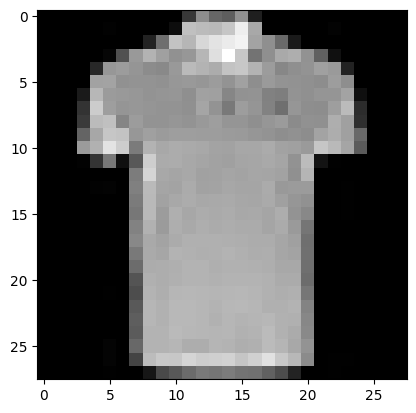

In [ ]:
#adapted from hackathon notebook, visualize an image and label
sample = next(iter(valid_set.take(1)))
img = sample['image'][0]
label_ind = sample['label'][0].numpy()
label= f_labels[label_ind]
print('Label: ', label)
f, axarr = plt.subplots(nrows=1, ncols=1)
axarr.imshow(img, cmap='gray')
plt.show()


In [ ]:
save_path_model=save_path+mod_name

In [ ]:
# early stopping with restore best weights
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=4,restore_best_weights=True)

#include sav_call in call backs in the model1.fit() if we want to save the model after a certain number of epochs
sav_call = SaveModelEpoch(save_str=save_path_model, epoch_interval= epoch_int)

In [ ]:
# Train model 1, maximum epochs is 40 but I'm expecting early stopping to halt much sooner
#early stopping is using the validation set loss
model1 = hw2_model1()
model1_rec= model1.fit(
        training_set,
        epochs=max_epoch,
        batch_size=32,
        validation_data=valid_set,
        callbacks=[early_stop],
        verbose=1
    )

#save final model
model1.save(save_path+'final_model.keras')

Epoch 1/40
1688/1688 [==============================] - 9s 5ms/step - loss: 0.5202 - accuracy: 0.8098 - val_loss: 0.4064 - val_accuracy: 0.8448
Epoch 2/40
1688/1688 [==============================] - 8s 5ms/step - loss: 0.4008 - accuracy: 0.8544 - val_loss: 0.3640 - val_accuracy: 0.8625
Epoch 3/40
1688/1688 [==============================] - 8s 5ms/step - loss: 0.3674 - accuracy: 0.8655 - val_loss: 0.3446 - val_accuracy: 0.8730
Epoch 4/40
1688/1688 [==============================] - 8s 5ms/step - loss: 0.3447 - accuracy: 0.8730 - val_loss: 0.3138 - val_accuracy: 0.8855
Epoch 5/40
1688/1688 [==============================] - 7s 4ms/step - loss: 0.3284 - accuracy: 0.8786 - val_loss: 0.3259 - val_accuracy: 0.8760
Epoch 6/40
1688/1688 [==============================] - 9s 5ms/step - loss: 0.3178 - accuracy: 0.8812 - val_loss: 0.3103 - val_accuracy: 0.8852
Epoch 7/40
1688/1688 [==============================] - 7s 4ms/step - loss: 0.3078 - accuracy: 0.8861 - val_loss: 0.2986 - val_accuracy:

In [ ]:
mod1_pred=model1.predict(testing_set)
mod1_pred=tf.argmax(mod1_pred, axis=1)
true_labels= np.concatenate([y for x, y in testing_set], axis=0)

In [ ]:
test_acc=accuracy_score(true_labels, mod1_pred)
print("Test accuracy: ", test_acc)

Test accuracy:  0.8812


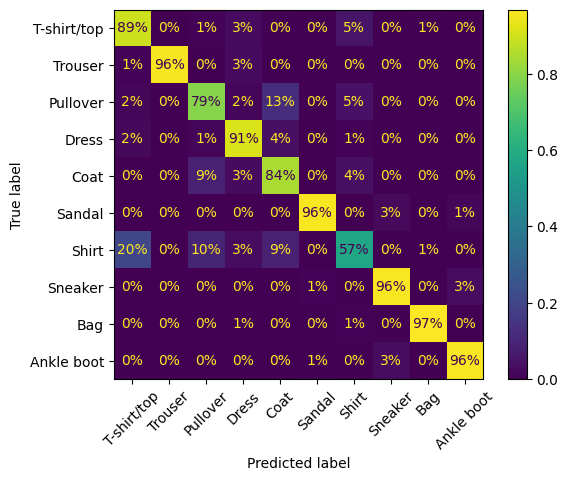

In [ ]:
ConfusionMatrixDisplay.from_predictions(true_labels, mod1_pred, normalize="true", values_format=".00%", display_labels=f_labels,xticks_rotation="45")

In [ ]:
#restore a model from save
model1_restore = tf.keras.models.load_model('saved_models/final_model.keras')